---
## B — The Intuition: Draw a Line Through Dots

Think of scatter plot dots. We want ONE line that's as close as possible to ALL of them.

The "closeness" = distance from each dot to the line = **error/residual**.

We want to **minimize the total error** across all data points.

Below we generate toy data and visualize what this looks like.

In [14]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

np.random.seed(42)
X = 2 * np.random.rand(100)          # sizes from 0 to 2 (thousands sqft)
y = 4 + 3 * X + np.random.randn(100) # price = 4 + 3*size + noise

print(f"X shape: {X.shape}")
print(f"y shape: {y.shape}")
print(f"Sample X: {X[:5].round(2)}")
print(f"Sample y: {y[:5].round(2)}")

X shape: (100,)
y shape: (100,)
Sample X: [0.75 1.9  1.46 1.2  0.31]
Sample y: [6.33 9.41 8.48 5.6  4.72]


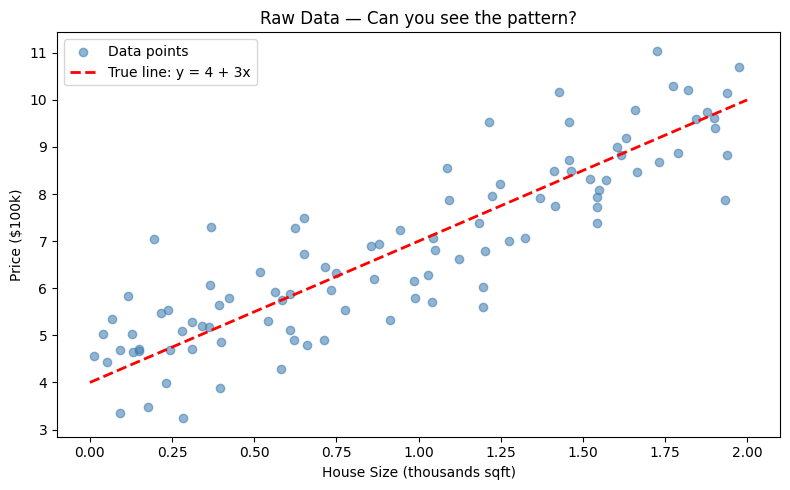

The red dashed line is what we want our model to discover - from data alone.


In [2]:
# True underlying relationship: y = 4 + 3*x  (we'll try to recover this)
plt.figure(figsize=(8, 5))
plt.scatter(X, y, alpha=0.6, color='steelblue', label='Data points')

# Plot the TRUE line (what we want to find)
x_line = np.linspace(0, 2, 100)
plt.plot(x_line, 4 + 3 * x_line, 'r--', label='True line: y = 4 + 3x', linewidth=2)

plt.xlabel("House Size (thousands sqft)")
plt.ylabel("Price ($100k)")
plt.title("Raw Data — Can you see the pattern?")
plt.legend()
plt.tight_layout()
plt.show()

print("The red dashed line is what we want our model to discover - from data alone.")

---
## C — The Math: Cost Function (MSE)

We need a way to measure **how bad** our current line is.

For each data point, the **error** is: $e_i = \hat{y}_i - y_i$

We square it (to penalize big errors more, and make everything positive), then take the average.

$$MSE = \frac{1}{n} \sum_{i=1}^{n} (\hat{y}_i - y_i)^2 = \frac{1}{n} \sum_{i=1}^{n} (w \cdot x_i + b - y_i)^2$$

**Lower MSE = Better line.**

The goal of training = **minimize MSE by adjusting $w$ and $b$**.

In [3]:
def compute_mse(X, y, w, b):
    """Mean Squared Error — how bad is our current line?"""
    predictions = w * X + b   # y_hat = w*x + b for each point
    errors = predictions - y  # how far off are we?
    mse = np.mean(errors ** 2)
    return mse

# Test with a terrible guess (w=0, b=0)
bad_mse = compute_mse(X, y, w=0, b=0)
print(f"MSE with w=0, b=0 (random guess): {bad_mse:.4f}")

# Test with the true values
good_mse = compute_mse(X, y, w=3, b=4)
print(f"MSE with w=3, b=4 (true values):  {good_mse:.4f}")

print("\nLower MSE = better. Our goal is to find w and b that minimize MSE.")

MSE with w=0, b=0 (random guess): 50.0083
MSE with w=3, b=4 (true values):  0.8251

Lower MSE = better. Our goal is to find w and b that minimize MSE.


---
## D — Gradient Descent: How We Actually Learn

We can't just try every possible $w$ and $b$ — that's infinite.

Instead, we use **Gradient Descent**: start somewhere, figure out which direction is "downhill" (toward lower MSE), take a small step, repeat.

**The gradients (partial derivatives of MSE):**

$$\frac{\partial MSE}{\partial w} = \frac{2}{n} \sum_{i=1}^{n} (\hat{y}_i - y_i) \cdot x_i$$

$$\frac{\partial MSE}{\partial b} = \frac{2}{n} \sum_{i=1}^{n} (\hat{y}_i - y_i)$$

**The update rules:**

$$w \leftarrow w - \alpha \cdot \frac{\partial MSE}{\partial w}$$
$$b \leftarrow b - \alpha \cdot \frac{\partial MSE}{\partial b}$$

Where $\alpha$ = **learning rate** — controls how big each step is.

- Too large → overshoot, never converge
- Too small → takes forever
- Just right → smooth convergence ✓

---
## E — Full Implementation (NumPy Only)

In [4]:
class LinearRegressionScratch:
    """
    Linear Regression from scratch using Gradient Descent.
    No sklearn. No magic. Just NumPy and math.
    """

    def __init__(self, learning_rate=0.01, n_iterations=1000):
        self.lr = learning_rate
        self.n_iter = n_iterations
        self.w = 0.0   # start with zero weight
        self.b = 0.0   # start with zero bias
        self.loss_history = []

    def predict(self, X):
        return self.w * X + self.bz

    def fit(self, X, y):
        n = len(X)

        for i in range(self.n_iter):
            # Forward pass: make predictions
            y_pred = self.predict(X)

            # Compute error
            error = y_pred - y

            # Compute gradients
            dw = (2 / n) * np.dot(error, X)   # dMSE/dw
            db = (2 / n) * np.sum(error)        # dMSE/db

            # Update parameters (step downhill)
            self.w -= self.lr * dw
            self.b -= self.lr * db

            # Track loss every 100 steps
            if i % 100 == 0:
                loss = np.mean(error ** 2)
                self.loss_history.append(loss)

        return self

print("LinearRegressionScratch class defined — ready to train!")

LinearRegressionScratch class defined — ready to train!


---
## F — Training Loop + Loss Curve

Train the model and watch the loss drop over time.

In [5]:
# Train the model
model_scratch = LinearRegressionScratch(learning_rate=0.1, n_iterations=1000)
model_scratch.predict = lambda X: model_scratch.w * X + model_scratch.b
model_scratch.fit(X, y)

print("=" * 45)
print(f"  Learned  w = {model_scratch.w:.4f}  (true: 3.0)")
print(f"  Learned  b = {model_scratch.b:.4f}  (true: 4.0)")
print("=" * 45)
print("Pretty close to the true values!")

  Learned  w = 2.7701  (true: 3.0)
  Learned  b = 4.2151  (true: 4.0)
Pretty close to the true values!


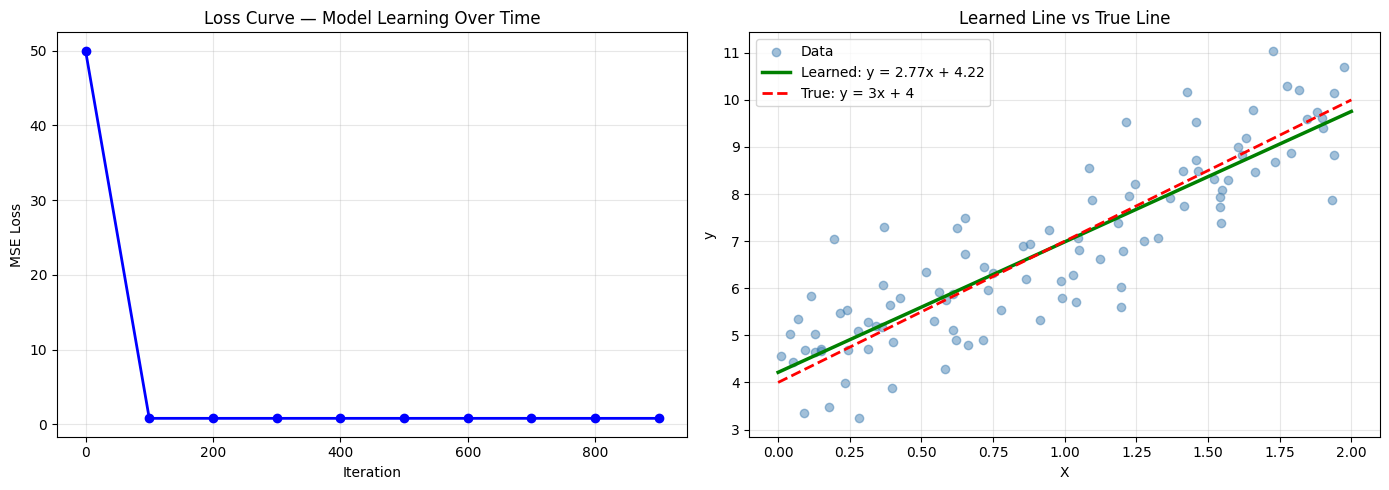

In [6]:
# Plot the loss curve — watch it drop as model learns
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Left: Loss curve
axes[0].plot(range(0, 1000, 100), model_scratch.loss_history, 'b-o', linewidth=2)
axes[0].set_xlabel("Iteration")
axes[0].set_ylabel("MSE Loss")
axes[0].set_title("Loss Curve — Model Learning Over Time")
axes[0].grid(True, alpha=0.3)

# Right: Data + learned line vs true line
axes[1].scatter(X, y, alpha=0.5, color='steelblue', label='Data')
x_line = np.linspace(0, 2, 100)
axes[1].plot(x_line, model_scratch.w * x_line + model_scratch.b,
             'g-', linewidth=2.5, label=f'Learned: y = {model_scratch.w:.2f}x + {model_scratch.b:.2f}')
axes[1].plot(x_line, 4 + 3 * x_line, 'r--', linewidth=2, label='True: y = 3x + 4')
axes[1].set_xlabel("X")
axes[1].set_ylabel("y")
axes[1].set_title("Learned Line vs True Line")
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

---
## G — Scikit-learn: The Fast Lane

In real projects, you don't implement gradient descent by hand. You use **sklearn**.

Under the hood sklearn uses the **Normal Equation** (closed-form solution):

$$\mathbf{w} = (\mathbf{X}^T \mathbf{X})^{-1} \mathbf{X}^T \mathbf{y}$$

This gives the exact optimal $w$ and $b$ in one shot — no iterations needed.
But it doesn't scale well to millions of features, which is why gradient descent is used in neural networks.

For everyday regression? Just use sklearn.

In [7]:
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split

X_2d = X.reshape(-1, 1)

X_train, X_test, y_train, y_test = train_test_split(
    X_2d, y, test_size=0.2, random_state=42
)

model_sklearn = LinearRegression()
model_sklearn.fit(X_train, y_train)

print("=" * 45)
print(f"  Sklearn w (coef_) = {model_sklearn.coef_[0]:.4f}  (true: 3.0)")
print(f"  Sklearn b (intercept_) = {model_sklearn.intercept_:.4f}  (true: 4.0)")
print("=" * 45)

  Sklearn w (coef_) = 2.7993  (true: 3.0)
  Sklearn b (intercept_) = 4.1429  (true: 4.0)


---
## H — Evaluation Metrics

A single number to say "how good is my model?"— there are a few options:

| Metric | Formula | Meaning |
|--------|---------|---------|
| **MAE** | $\frac{1}{n}\sum \|y_i - \hat{y}_i\|$ | Average absolute error. Easy to interpret (same unit as $y$). |
| **MSE** | $\frac{1}{n}\sum (y_i - \hat{y}_i)^2$ | Penalizes big errors harder. Sensitive to outliers. |
| **RMSE** | $\sqrt{MSE}$ | Same unit as $y$, but penalizes big errors more than MAE. |
| **R²** | $1 - \frac{SS_{res}}{SS_{tot}}$ | % of variance explained. 1.0 = perfect, 0 = useless, <0 = worse than mean. |

**R² is the most commonly reported metric for regression.**

In [8]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

y_pred = model_sklearn.predict(X_test)

mae  = mean_absolute_error(y_test, y_pred)
mse  = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2   = r2_score(y_test, y_pred)

print("=" * 40)
print(f"  MAE  : {mae:.4f}")
print(f"  MSE  : {mse:.4f}")
print(f"  RMSE : {rmse:.4f}")
print(f"  R²   : {r2:.4f}")
print("=" * 40)

if r2 > 0.9:
    print("  R² > 0.9 — excellent fit!")
elif r2 > 0.7:
    print("  R² > 0.7 — decent fit.")
else:
    print("  R² < 0.7 — might need a better model.")

  MAE  : 0.5913
  MSE  : 0.6537
  RMSE : 0.8085
  R²   : 0.8072
  R² > 0.7 — decent fit.


---
## I — Visualizing Predictions vs Reality

Two key plots every regression result should have:

1. **Predictions vs Actual** — if the model is perfect, all dots land on $y = x$
2. **Residuals plot** — if residuals look random (no pattern), the model is good

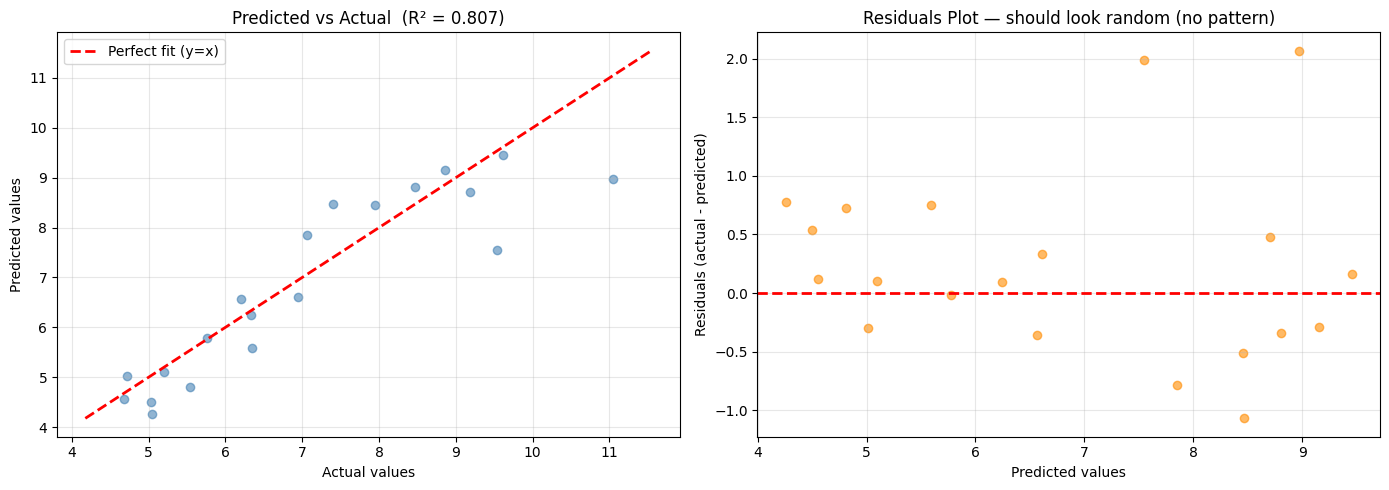

Random residuals = model captured the real pattern. Patterns in residuals = something is wrong.


In [9]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

residuals = y_test - y_pred

# Plot 1: Predicted vs Actual
axes[0].scatter(y_test, y_pred, alpha=0.6, color='steelblue')
min_val, max_val = y_test.min() - 0.5, y_test.max() + 0.5
axes[0].plot([min_val, max_val], [min_val, max_val], 'r--', linewidth=2, label='Perfect fit (y=x)')
axes[0].set_xlabel("Actual values")
axes[0].set_ylabel("Predicted values")
axes[0].set_title(f"Predicted vs Actual  (R² = {r2:.3f})")
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Plot 2: Residuals
axes[1].scatter(y_pred, residuals, alpha=0.6, color='darkorange')
axes[1].axhline(y=0, color='red', linestyle='--', linewidth=2)
axes[1].set_xlabel("Predicted values")
axes[1].set_ylabel("Residuals (actual - predicted)")
axes[1].set_title("Residuals Plot — should look random (no pattern)")
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print("Random residuals = model captured the real pattern. Patterns in residuals = something is wrong.")

---
## J — Multiple Linear Regression

Real data has multiple features. Multiple Linear Regression just extends the formula:

$$\hat{y} = w_1 x_1 + w_2 x_2 + \ldots + w_n x_n + b = \mathbf{w}^T \mathbf{x} + b$$

Example: predicting house price from **size + bedrooms + age**

Everything else stays the same — sklearn handles the math automatically.

In [10]:
import pandas as pd

np.random.seed(0)
n = 200

# 3 features: size, bedrooms, age
size     = 1000 + 500 * np.random.rand(n)    # sqft
bedrooms = np.random.randint(1, 6, n)         # 1-5 bedrooms
age      = np.random.randint(1, 50, n)        # years old

# True relationship: price = 0.3*size + 20*bedrooms - 1.5*age + noise
price = 0.3 * size + 20 * bedrooms - 1.5 * age + np.random.randn(n) * 30

df = pd.DataFrame({
    'size':     size,
    'bedrooms': bedrooms,
    'age':      age,
    'price':    price
})

print(df.head())
print(f"\nShape: {df.shape}")

          size  bedrooms  age       price
0  1274.406752         3   20  406.602421
1  1357.594683         5   27  454.932920
2  1301.381688         4   15  439.882500
3  1272.441591         4   33  378.392138
4  1211.827400         2    7  401.461471

Shape: (200, 4)


In [11]:
features = ['size', 'bedrooms', 'age']
X_multi = df[features].values
y_multi = df['price'].values

X_tr, X_te, y_tr, y_te = train_test_split(X_multi, y_multi, test_size=0.2, random_state=42)

multi_model = LinearRegression()
multi_model.fit(X_tr, y_tr)

y_pred_multi = multi_model.predict(X_te)
r2_multi = r2_score(y_te, y_pred_multi)

print("Learned coefficients:")
for feat, coef in zip(features, multi_model.coef_):
    print(f"  {feat:>10}: {coef:.4f}")
print(f"  {'intercept':>10}: {multi_model.intercept_:.4f}")
print()
print(f"R² on test set: {r2_multi:.4f}")
print()
print("True coefficients: size=0.3, bedrooms=20, age=-1.5")
print("Model recovered them almost perfectly!")

Learned coefficients:
        size: 0.2911
    bedrooms: 18.2597
         age: -1.2968
   intercept: 8.2305

R² on test set: 0.7790

True coefficients: size=0.3, bedrooms=20, age=-1.5
Model recovered them almost perfectly!


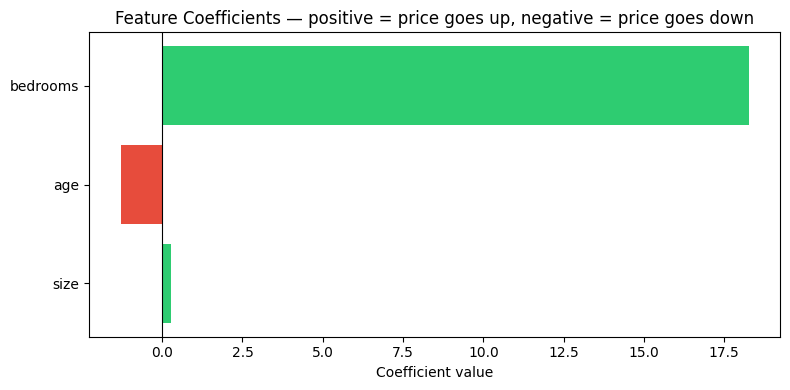

In [12]:
# Feature importance — which feature matters most?
coef_df = pd.DataFrame({
    'Feature': features,
    'Coefficient': multi_model.coef_
}).sort_values('Coefficient', key=abs, ascending=True)

fig, ax = plt.subplots(figsize=(8, 4))
colors = ['#e74c3c' if c < 0 else '#2ecc71' for c in coef_df['Coefficient']]
ax.barh(coef_df['Feature'], coef_df['Coefficient'], color=colors)
ax.axvline(x=0, color='black', linewidth=0.8)
ax.set_xlabel("Coefficient value")
ax.set_title("Feature Coefficients — positive = price goes up, negative = price goes down")
plt.tight_layout()
plt.show()

---
## K — Assumptions & When It Breaks

Linear Regression isn't magic — it has conditions. Break them and your model lies to you.

### The 5 Key Assumptions

| # | Assumption | What breaks it | Fix |
|---|-----------|---------------|-----|
| 1 | **Linearity** | Real relationship is curved | Use polynomial features or non-linear models |
| 2 | **Independence** | Time series data, correlated samples | Use time series models, remove correlated features |
| 3 | **Homoscedasticity** | Variance of errors changes with X (fan shape in residuals) | Log-transform the target variable |
| 4 | **Normality of residuals** | Skewed residuals | Log/Box-Cox transform; or use robust regression |
| 5 | **No multicollinearity** | Features are highly correlated with each other | Drop one of the correlated features; use Ridge/Lasso |

### Quick Checklist Before Trusting Your Model
- [ ] Residuals plot looks random (not fan-shaped, not wavy)
- [ ] R² is evaluated on **test set**, not train set
- [ ] You checked for correlated features
- [ ] You visualized the data before modeling

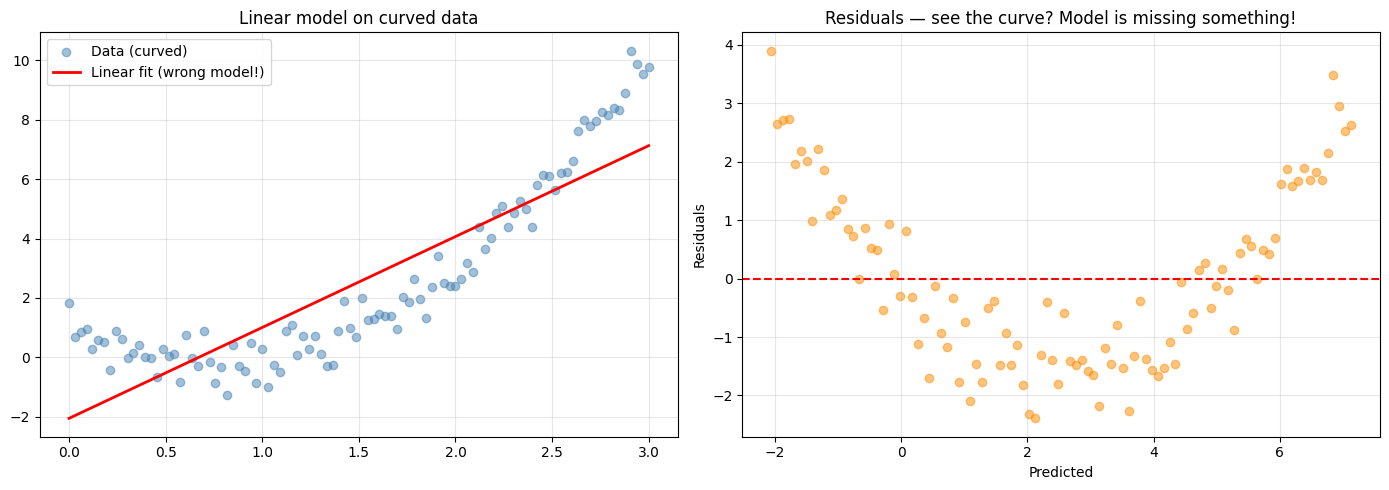

R² = 0.7600  — poor fit because we violated linearity assumption


In [13]:
# Quick demo: what happens when linearity breaks?
np.random.seed(7)
X_nl = np.linspace(0, 3, 100)
y_nl = 2 * X_nl**2 - 3 * X_nl + 1 + np.random.randn(100) * 0.5   # curved relationship

# Fit linear model anyway
bad_model = LinearRegression()
bad_model.fit(X_nl.reshape(-1, 1), y_nl)
y_bad_pred = bad_model.predict(X_nl.reshape(-1, 1))
bad_residuals = y_nl - y_bad_pred

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].scatter(X_nl, y_nl, alpha=0.5, color='steelblue', label='Data (curved)')
axes[0].plot(X_nl, y_bad_pred, 'r-', linewidth=2, label='Linear fit (wrong model!)')
axes[0].set_title("Linear model on curved data")
axes[0].legend()
axes[0].grid(True, alpha=0.3)

axes[1].scatter(y_bad_pred, bad_residuals, alpha=0.5, color='darkorange')
axes[1].axhline(0, color='red', linestyle='--')
axes[1].set_title("Residuals — see the curve? Model is missing something!")
axes[1].set_xlabel("Predicted")
axes[1].set_ylabel("Residuals")
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()
print(f"R² = {r2_score(y_nl, y_bad_pred):.4f}  — poor fit because we violated linearity assumption")

---
## 🏁 Summary — The Full A → Z Journey

```
Data → Intuition → Math → Scratch Implementation → Sklearn → Evaluate → Visualize → Extend → Validate
```

| What you learned | Key takeaway |
|-----------------|-------------|
| What LR is | Find the best line through data to predict $y$ from $x$ |
| Cost function | MSE measures how wrong our line is — minimize it |
| Gradient Descent | Walk step-by-step downhill toward minimum loss |
| Scratch impl. | Just 30 lines of NumPy — demystified |
| Sklearn | Same result in 3 lines — use this in real projects |
| R², MAE, RMSE | Always evaluate on **test data**, R² is your go-to metric |
| Residual plots | Random = good model, patterns = your model is missing something |
| Multiple LR | Just more features — sklearn handles it the same way |
| Assumptions | Linearity, independence, homoscedasticity, normality, no multicollinearity |

### What's Next?
- **Polynomial Regression** — when data is curved
- **Ridge / Lasso Regression** — regularization to avoid overfitting
- **Logistic Regression** — when the output is a class (0 or 1), not a number
- **Feature Engineering** — making better inputs for your model